# NOVARA COHORT 2025
# CAPSTONE PROJECT FOR GROUP 16
## Track 3: Time Series Analysis (Forecasting Truck Sales)
**Objective:**
Forecast monthly truck sales using time series modeling (SARIMA) after performing full exploratory data analysis and preprocessing.

**The data set used is Truck Data yearly sales; source: https://www.kaggle.com/datasets/ddosad/dummy-truck-sales-for-time-series**

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [20]:
# LOAD DATASET

df = pd.read_csv("C:/Users/User/Downloads/Truck_sales_033633.csv")

## Dataset Overview
We examine the structure of the dataset including:
- preview of the dataset
- rows and columns
- data types
- memory usage
- basic statistics of the dataset

In [21]:
df.head(5)

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Month-Year          144 non-null    object
 1   Number_Trucks_Sold  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 144
Columns: 2


In [17]:
df.describe()

,Number_Trucks_Sold
count,144.000000
mean,428.729167
std,188.633037
min,152.000000
25%,273.500000
50%,406.000000
75%,560.250000
max,958.000000


## Data Preprocessing
**since the Month-Year column is in day-month format, convert to year-month-day format.**

**Convert Month-Year column to datetime.**

In [22]:
df['Month-Year'] = pd.to_datetime('20' + df['Month-Year'], format='%Y-%b')
df.set_index('Month-Year', inplace=True)

df = df.sort_index()

df.head()

,Number_Trucks_Sold
Month-Year,
2003-01-01,155
2003-02-01,173
2003-03-01,204
2003-04-01,219
2003-05-01,223


## Missing Values Analysis

In [23]:
df.isna()

,Number_Trucks_Sold
Month-Year,
2003-01-01,False
2003-02-01,False
2003-03-01,False
2003-04-01,False
2003-05-01,False
...,...
2014-08-01,False
2014-09-01,False
2014-10-01,False


In [24]:
df.isnull().sum()

Number_Trucks_Sold    0
dtype: int64

**No missing value recorded in the dataset**

## Numerical features analysis
**Visualisation of the numerical column using:**
- Histogram
- boxplot
  
and performance of basic statistics. 

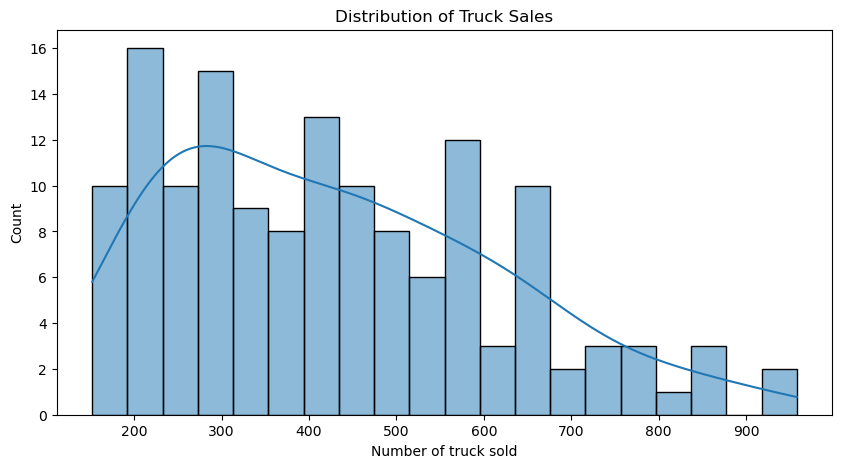

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(df["Number_Trucks_Sold"],kde=True, bins=20)
plt.xlabel("Number of truck sold")
plt.title("Distribution of Truck Sales")
plt.show()

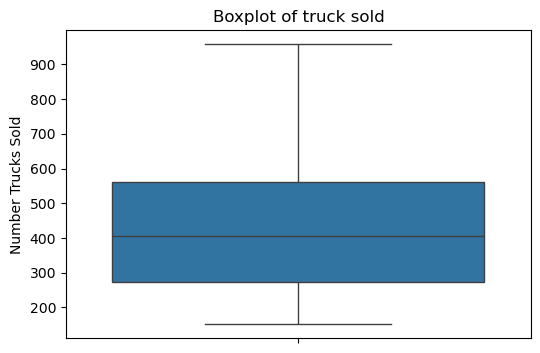

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, y="Number_Trucks_Sold")
#plt.ylabel("Number of truck sold")
plt.title("Boxplot of truck sold")
plt.ylabel("Number Trucks Sold")
plt.show()

In [27]:
df["Number_Trucks_Sold"].describe()

count    144.000000
mean     428.729167
std      188.633037
min      152.000000
25%      273.500000
50%      406.000000
75%      560.250000
max      958.000000
Name: Number_Trucks_Sold, dtype: float64

**from the statistical analysis of the numerical column, since the mean is higher than the median, it indicates that the distribution is right skewed**

## Univariate Analysis

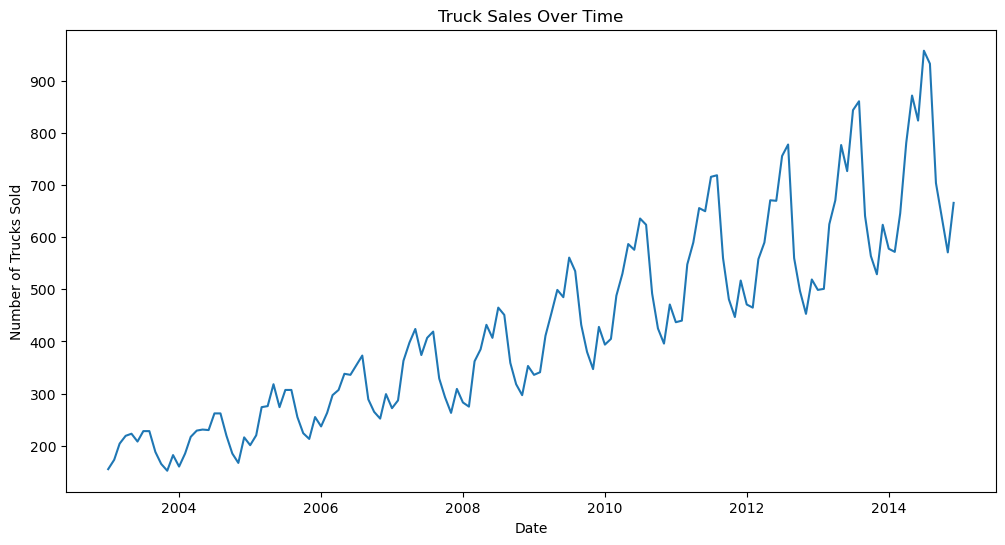

In [28]:
plt.figure(figsize=(12,6))
plt.plot(df["Number_Trucks_Sold"])
plt.title("Truck Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Trucks Sold")
plt.show()

# Time Series Analysis:

**1. Time series plot with trend line**


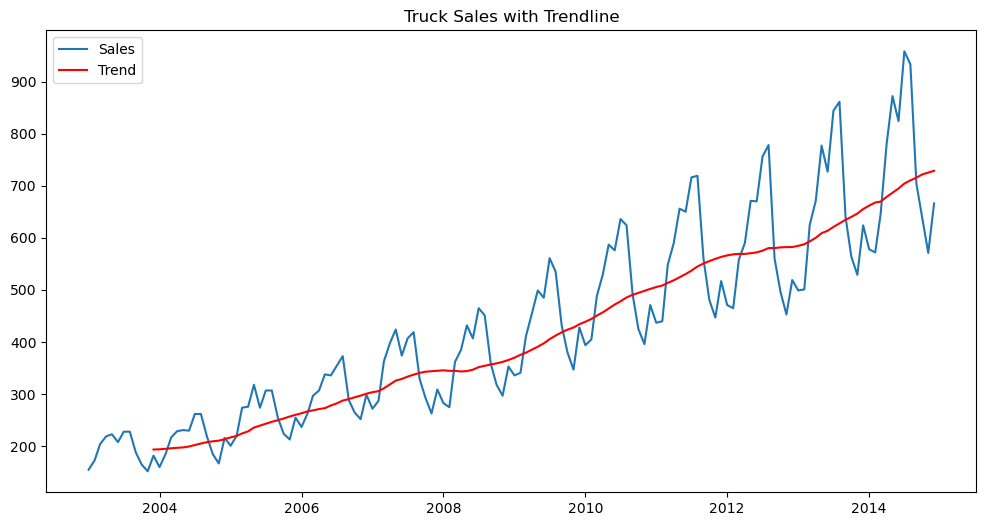

In [29]:
plt.figure(figsize=(12,6))

plt.plot(df["Number_Trucks_Sold"], label="Sales")
df['Trend'] = df['Number_Trucks_Sold'].rolling(window=12).mean()
plt.plot(df['Trend'], label="Trend", color='red')
plt.title("Truck Sales with Trendline")
plt.legend()
plt.show()

**2. Time series decomposition showing trend, seasonality and residual**

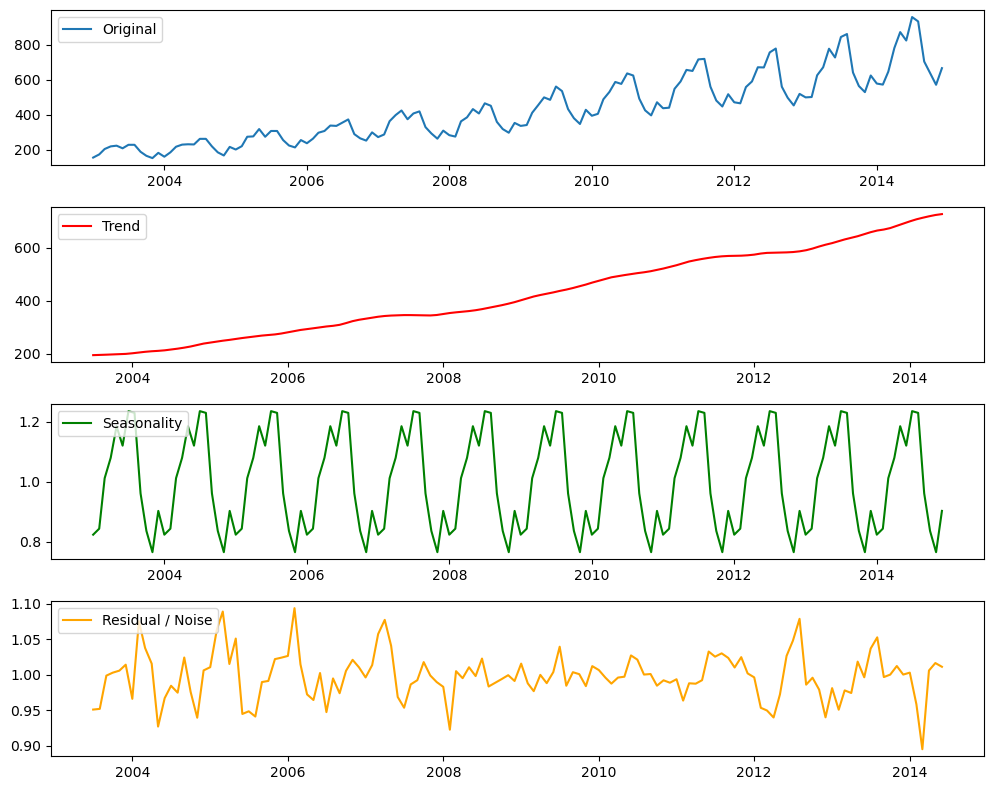

In [30]:
decomposition = seasonal_decompose(df['Number_Trucks_Sold'], model="multiplicative", period=12)

Trend=decomposition.trend
seasonal=decomposition.seasonal
residual=decomposition.resid

plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(df['Number_Trucks_Sold'], label='Original')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(Trend, label='Trend', color='red')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual / Noise', color='orange')
plt.legend(loc='upper left')

plt.tight_layout()

plt.show()

**3. Stationarity testing using Augmented Dickey-Fuller test**

In [31]:
adf_test = adfuller(df["Number_Trucks_Sold"])

print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

if adf_test[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary, apply first order or/and seasonality differencing")

ADF Statistic: 1.1158932574252705
p-value: 0.9953500083802602
The series is likely non-stationary, apply first order or/and seasonality differencing


**4. Differencing of non-stationary data, and applying the ADF TEST**

ADF Statistic: -2.5413553267699096
p-value: 0.10573354923819811
The series is likely non-stationary, apply seasonal differencing


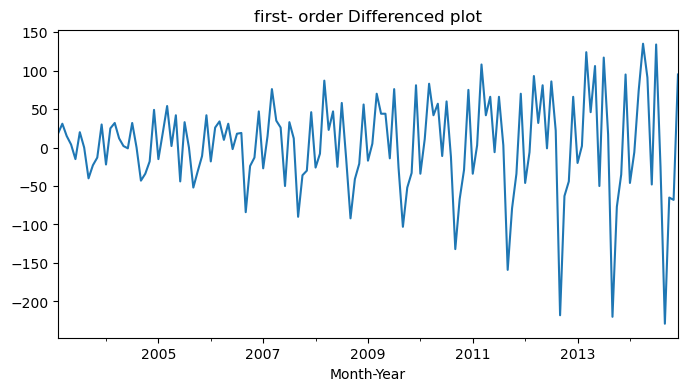

In [33]:
df["diff"] = df["Number_Trucks_Sold"] - df["Number_Trucks_Sold"].shift(1) # first order differencing
df_diff = df["diff"].dropna()


df_adf = adfuller(df_diff)

print("ADF Statistic:", df_adf[0])
print("p-value:", df_adf[1])

if df_diff[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary, apply seasonal differencing")

df_diff.plot(figsize=(8,4)) # plot of the first-order differenced dataset

plt.title("first- order Differenced plot")

plt.show()

ADF Statistic: -3.507930040939536
p-value: 0.007785754185827366
The series is likely stationary


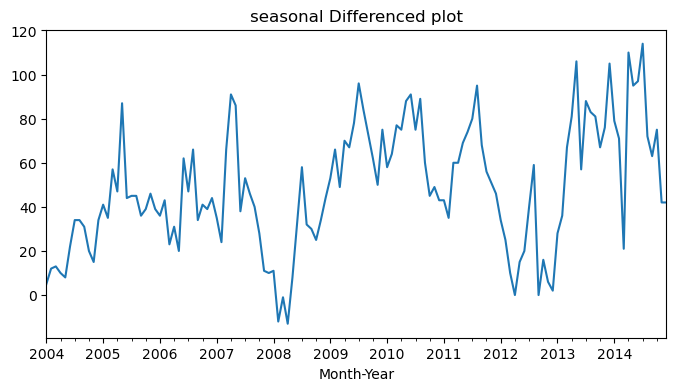

In [34]:
df["diff_s"] = df["Number_Trucks_Sold"] - df["Number_Trucks_Sold"].shift(12) #seasonal differencing using a 12 month shift

df_diff_s = df["diff_s"].dropna() #drop missing values


result_adf = adfuller(df_diff_s)

print("ADF Statistic:", result_adf[0])
print("p-value:", result_adf[1])

if result_adf[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary, apply seasonality differencing")

df_diff_s.plot(figsize=(8,4)) # plot of the first-order differenced dataset

plt.title("seasonal Differenced plot")

plt.show()

**5. ACF and PACF plots**

<Figure size 1200x500 with 0 Axes>

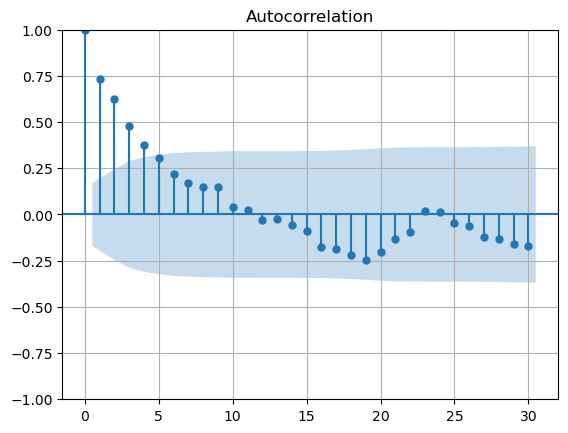

<Figure size 1200x500 with 0 Axes>

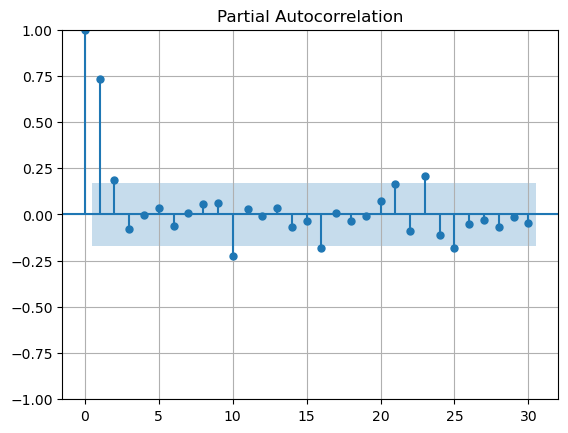

In [35]:
plt.figure(figsize=(12,5))

plot_acf(df_diff_s, lags=30)
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))

plot_pacf(df_diff_s, lags=30)
plt.grid(True)
plt.show()


from the ACF/PCF PLOT, order to consider (1,1,3)

**6. Train-Test split**

In [36]:
train_size = int(len(df)*0.8)

train = df["Number_Trucks_Sold"][:train_size]
test = df["Number_Trucks_Sold"][train_size:]

In [37]:
train.tail()

Month-Year
2012-03-01    558
2012-04-01    590
2012-05-01    671
2012-06-01    670
2012-07-01    756
Name: Number_Trucks_Sold, dtype: int64

In [38]:
test.head()

Month-Year
2012-08-01    778
2012-09-01    560
2012-10-01    497
2012-11-01    453
2012-12-01    519
Name: Number_Trucks_Sold, dtype: int64

**Plot of the Train-Test split dataset**

<function matplotlib.pyplot.show(close=None, block=None)>

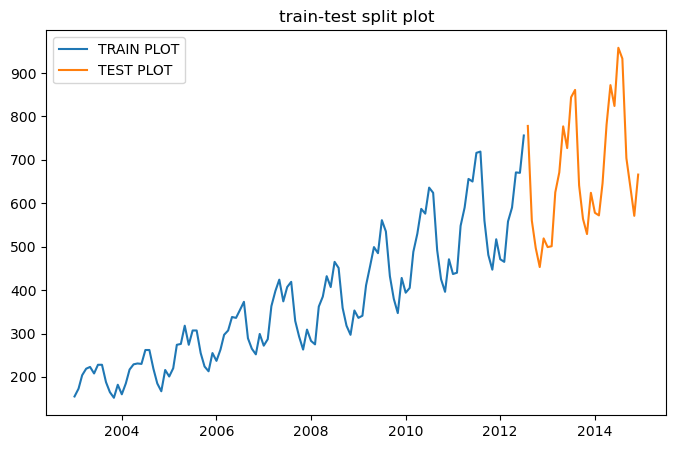

In [39]:
plt.figure(figsize=(8,5))
plt.plot(train, label = "TRAIN PLOT")
plt.plot(test, label = "TEST PLOT")
plt.legend()
plt.title("train-test split plot")
plt.show

**7. Building the SARIMA MODEL**

In [40]:
model = SARIMAX(train,order = (1,1,3), seasonal_order = (1,1,3,12))

results = model.fit()


**8. Forecast/plot**

In [41]:
forecast = results.forecast(steps=len(test))

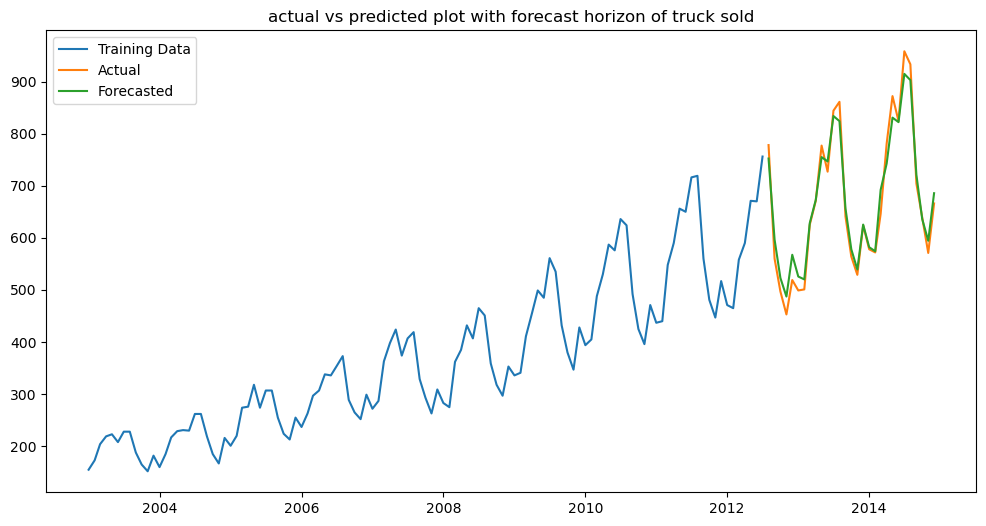

In [42]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecasted")
plt.legend()
plt.title("actual vs predicted plot with forecast horizon of truck sold")
plt.show()

**Residual Analysis**

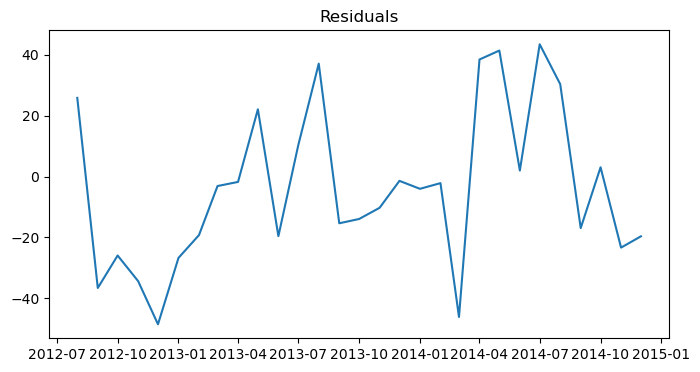

In [43]:
residuals = test - forecast

plt.figure(figsize=(8,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

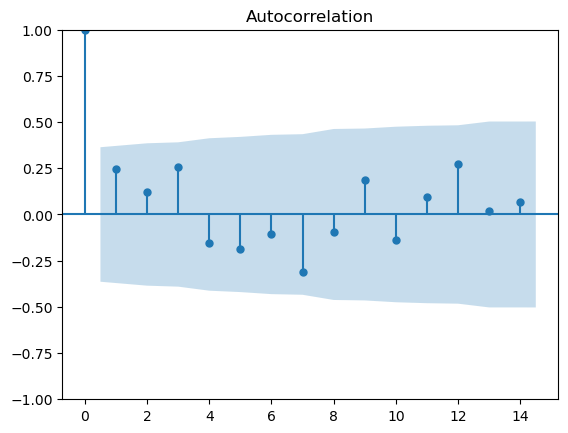

In [44]:
plot_acf(residuals.dropna())
plt.show() #Autoco

**future prediction using the `.get_forecast()`function**

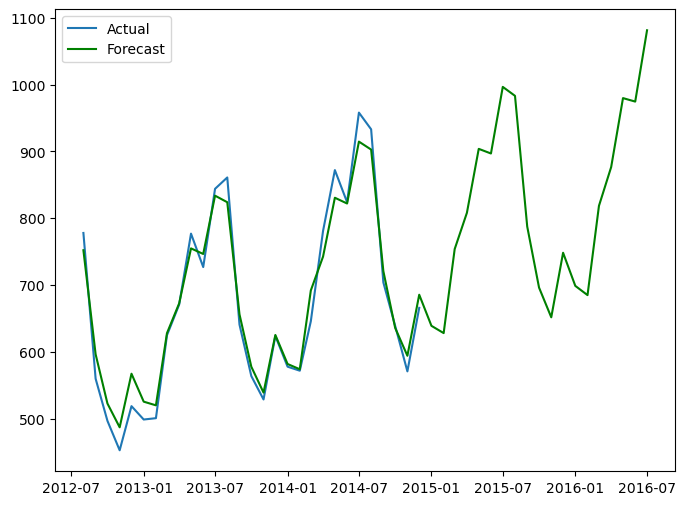

In [45]:
forecast = results.get_forecast(steps=48) # 48 monts interval

plt.figure(figsize=(8, 6))
plt.plot(test, label='Actual')
plt.plot(forecast.predicted_mean, label='Forecast', color='green') # this plot extracts the predicted values over the given period selected
plt.legend()
plt.show()

**9. The forecasting accuracy of the SARIMA model was evaluated using MAE, RMSE, RMS, and MAPE. The model produced a MAPE of 3.30%, indicating** **excellent forecasting performance since the average prediction error is below 10%. Furthermore, the RMSE (25.96) is close to the MAE (21.46),** **suggesting that the forecast errors are relatively stable without significant outliers. Overall, the model demonstrates good predictive capability** **for the time series data.**

In [52]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred = forecast.predicted_mean
actual, pred = test.align(pred, join='inner')
residuals = actual - pred
rms = np.sqrt(np.mean(residuals**2))
rmse = np.sqrt(mean_squared_error(actual, pred))

MAE = mean_absolute_error(actual, pred)
MAPE = np.mean(np.abs((actual - pred) / actual)) * 100
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "RMS", "MAPE (%)"],
    "Value": [MAE, rmse, rms, MAPE]
})


print("Forecast Accuracy Metrics")
print("-------------------------")
print(results)


Forecast Accuracy Metrics
-------------------------
     Metric      Value
0       MAE  21.463660
1      RMSE  25.959928
2       RMS  25.959928
3  MAPE (%)   3.304060


**Model Diagnostics**

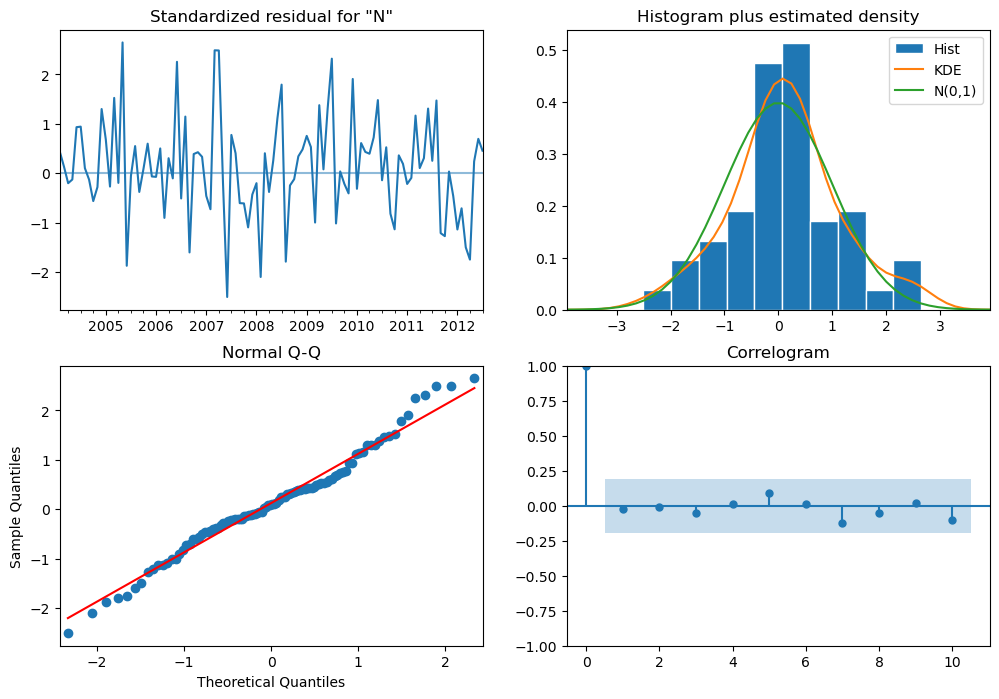

In [46]:
results.plot_diagnostics(figsize=(12,8))
plt.show()

**The model diagnostics indicates that the SARIMA model used is suitable for the analysis. This can be seen from the HISTOGRAM and  Q-Q plot, as the residual points populates the zero region of the plot and also depicts a normal distribution. Moreso, the CORRELOGRAM plot shows that majority of the modeled data falls within the confidence boundary, henced, behaving like white noise. this is a clear indication that the model is a good fit for forecasting.**

**RESULT AND CONCLUSION**


The Mean Absolute Error (MAE) of approximately 21.46 indicates that, on average, the forecasted values deviate from the actual observations by about 21 units. Considering the scale of the data, this level of deviation is relatively small and suggests that the model provides reasonably accurate predictions.

The Root Mean Squared Error (RMSE) value of 25.96 measures the square root of the average squared differences between predicted and observed values. Since RMSE penalizes larger errors more heavily than MAE, the relatively close values of MAE and RMSE suggest that the model does not produce large forecasting errors or extreme deviations.

The Root Mean Square (RMS) value is identical to the RMSE in this case, confirming the consistency of the residual-based error calculations.

The Mean Absolute Percentage Error (MAPE) is 3.30%, which indicates that the model's predictions differ from the actual values by an average of only 3.3%. In time series forecasting, a MAPE value below 10% is generally considered to represent excellent forecasting performance. Therefore, the SARIMA model demonstrates strong predictive accuracy

**CONCLUSION**

This study applied a Seasonal Autoregressive Integrated Moving Average (SARIMA) model to analyze and forecast the time series data. The model was fitted after examining the trend and seasonal patterns present in the dataset and selecting appropriate parameters.

The evaluation results show that the model performs well in capturing the underlying structure of the data. The relatively low MAE and RMSE values indicate that the forecast errors are small and stable. Additionally, the very low MAPE value of 3.30% suggests that the model provides highly accurate predictions relative to the magnitude of the observed data.

Overall, the SARIMA model proves to be an effective tool for forecasting the given time series. The results demonstrate that the model can reliably predict future values with a high degree of accuracy, making it suitable for forecasting and decision-making purposes based on the analyzed dataset.

**CHALLENGES**

The challenges faced in this project stemmed from sourcing of the dataset. More than three (3) datasets were used in trial before the final dataset 
which was used in this project. Another challenge faced was writing the code accurately to correctly fit the model. However, with relentless and consistent
effort shown by some prominent members of the group, we managed to understand and finally came up with a solution which led to a decent and near accurate
Time series Model. 

**RECOMMENDATIONS**

On behalf of all group members, we recommend that datasets and topics for project should be made available for uniformity to students to successfully carry out the project, for an intermediate course. 

**ACKNOWLEDGEMENT**

Firstly, we appreciate God almighty for granting us the knowledge and wisdom to carry out this research which led to a successful project. We also appreciate the TS Academy management for the scholarship which is a life changing opportunity to everyone in the group. We also appreciate our tutur Mr. Hart who took gave us the foundation and the building block of our knowledge. Lastly we appreciate all group members who worked relentlessly and collaboratively to carry out research and see to the successful submission of this project.  

**NAMES OF ACTIVE GROUP MEMBERS**

1. Name: Umar Yahaya
   Email: umarbebeji24@gmail.com
   Github:https://github.com/Umarvc01/CAPSTONE-PROJECT-ON-TIMESERIES-MODELING-
   
3. Name: Fagbayi Boluwatife Sandra
   Email: fagbayisandra.7@gmail.com
   Github:https://github.com/fagbayisandra7-create/TS_Academy_Capstone_Project_
   
4. Name: Awhen, Denis
   Email: awhendenis018@yahoo.com
   Github:https://github.com/awhen-denis/TS_Academy_Capstone_Project-

5. Name: Shorunke Abdulazeem
   Email: itazeeem10@gmail.com
   Github:https://github.com/Azo-rocks/TS_Academy_Capstone_Project

6. Name: Ajimajasan Faith Olusola 
   Email: faith.ajimajasan@gmail.com
   Github:https://github.com/SurMan2026/TS_Academy_Capstone_Project

7. Name: Musediq Adeniran
   Email:ademusediq@gmail.com
   Github:https://github.com/musediq/TS_Academy_Capstone_Project

8. Name: Amoke Joshua Chibuikem
   Email: joshuaolaniyi518@gmail.com
   Github:https://github.com/InsightTN/Capstone-Project.git

9. Name: Egbuna Chisom Ifechukwu 
   Email: Chisomifechukwu@gmail.com 
   Github:https://github.com/Chukwu-som/TS_Academy_Capstone_Project
    